# Лабораторна робота №6: Задачі класифікації

### Мета роботи

Опанувати повний цикл побудови та оцінки моделей бінарної класифікації. Навчитися готувати дані, тренувати **дві моделі різних родин** — лінійну (Logistic Regression) та інстансно-орієнтовану (k-Nearest Neighbors), оцінювати їх якість за допомогою релевантних метрик та обирати поріг класифікації відповідно до бізнес-вимог.

---

### Набір даних: Palmer Penguins

Морфологічні виміри 344 пінгвінів трьох видів (*Adelie*, *Chinstrap*, *Gentoo*) з архіпелагу Палмер в Антарктиці. Цей набір уже використовувався у Лабораторній роботі №3, тому його структура вам знайома.

**Задача:** передбачити **стать** пінгвіна (`sex`) за його морфологічними характеристиками та видовою/географічною приналежністю. Це задача бінарної класифікації, що спирається на біологічне явище **статевого диморфізму**: у пінгвінів самці зазвичай більші за самок у межах одного виду.

**Ключові моменти:**
- Цільова змінна — `sex` (Male / Female). За домовленістю позитивним вважатимемо клас «Female» (1).
- 11 рядків мають пропуски у `sex` — їх потрібно виключити, бо мітки не імпутуються. 2 рядки мають пропуски у числових ознаках — їх імпутуємо.

---

## Підготовчий блок

Виконайте наступні комірки без змін — вони готують середовище та завантажують дані.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
sns.set_palette('Set2')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Завантаження даних: спершу seaborn, потім локальний CSV, у крайньому разі — синтетичні дані.
import os

df = None
df = sns.load_dataset('penguins')

display(df.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---

## Розділ 1. Підготовка даних


### 1.1 Очищення, кодування та поділ на train/test

- Видаліть рядки, у яких **відсутня цільова змінна** `sex`.
- Заповніть пропуски у числових ознаках обґрунтованим способом. Поясніть свій вибір у 1-2 реченнях.
- Закодуйте категоріальні ознаки у числовий формат, придатний для усіх класифікаторів.
- Закодуйте цільову змінну `sex` у бінарний формат: 1 = Female, 0 = Male.
- Виконайте поділ на навчальну (75%) та тестову (25%) вибірки **зі стратифікацією** за цільовою змінною та фіксованим `random_state=42`. Перевірте, що частка позитивного класу збереглася в обох вибірках.

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# --- Завантаження через palmerpenguins (не потребує мережі) ---
try:
    from palmerpenguins import load_penguins
    df = load_penguins()
except ImportError:
    pass  # df вже завантажено вище через sns

# Видаляємо рядки без цільової змінної (11 рядків)
df = df.dropna(subset=['sex']).copy()

# Медіанна імпутація числових ознак (менш чутлива до викидів, ніж середнє)
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

# One-hot кодування категоріальних ознак
df = pd.get_dummies(df, columns=['species', 'island'], drop_first=False)

# Цільова змінна: Female=1, Male=0
df['target'] = (df['sex'].str.lower() == 'female').astype(int)

feature_cols = [c for c in df.columns if c not in ['sex', 'year', 'target']]
X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} зразків | Test: {len(X_test)} зразків")
print(f"Частка Female — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")


Train: 249 зразків | Test: 84 зразків
Частка Female — Train: 0.494 | Test: 0.500


---

## Розділ 2. Побудова та порівняння моделей

У цьому розділі ви навчите дві моделі на тих самих тренувальних даних і порівняєте їх якість на тестовій вибірці.

### 2.1 Logistic Regression

- Обов'язково виконайте **масштабування числових ознак** перед навчанням.
- Навчіть модель з `random_state=42` та `max_iter=1000` (для надійної збіжності оптимізатора).
- Виконайте передбачення на тестовій вибірці.
- Виведіть матрицю невідповідностей (confusion matrix) у вигляді heatmap .
- Обчисліть та виведіть у вигляді таблиці: **accuracy, precision, recall, F1-score** для позитивного класу (Female).
- Виведіть **коефіцієнти моделі** для кожної ознаки. У markdown-комірці інтерпретуйте знаки коефіцієнтів: які ознаки штовхають передбачення в бік «Female», а які — в бік «Male»? Чи відповідає це біологічним очікуванням?


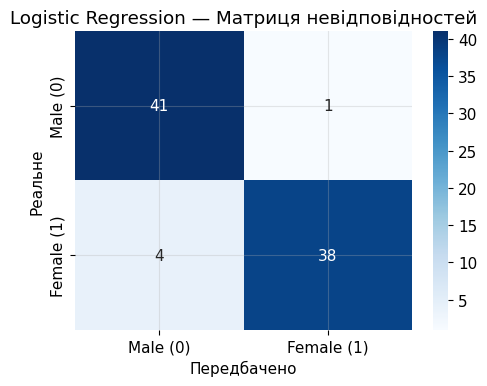

Метрики Logistic Regression:


,Accuracy,Precision,Recall,F1-score
0,0.9405,0.9744,0.9048,0.9383


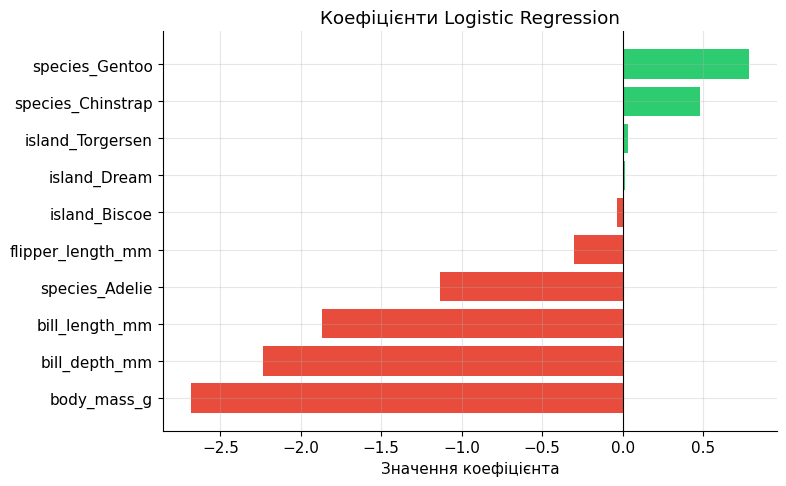

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Масштабування числових ознак
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Навчання моделі
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Male (0)', 'Female (1)'],
            yticklabels=['Male (0)', 'Female (1)'], ax=ax)
ax.set_xlabel('Передбачено')
ax.set_ylabel('Реальне')
ax.set_title('Logistic Regression — Матриця невідповідностей')
plt.tight_layout()
plt.show()

# Метрики
metrics_lr = pd.DataFrame([{
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-score': f1_score(y_test, y_pred_lr),
}]).round(4)
print("Метрики Logistic Regression:")
display(metrics_lr)

# Коефіцієнти моделі
coef_df = pd.DataFrame({'Ознака': feature_cols, 'Коефіцієнт': lr.coef_[0]})
coef_df = coef_df.sort_values('Коефіцієнт').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef_df['Коефіцієнт']]
ax.barh(coef_df['Ознака'], coef_df['Коефіцієнт'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Коефіцієнти Logistic Regression')
ax.set_xlabel('Значення коефіцієнта')
plt.tight_layout()
plt.show()


**Інтерпретація коефіцієнтів:**

Від'ємні коефіцієнти (body_mass_g, bill_depth_mm, bill_length_mm) штовхають модель у бік «Male» — самці великі та масивніші. Позитивні коефіцієнти (species_Gentoo, species_Chinstrap) штовхають у бік «Female». Це відповідає біологічному явищу статевого диморфізму: самці більші за самок у межах одного виду, тому великі розміри — ознака самця.


### 2.2 k-Nearest Neighbors

- Використовуйте ті самі **відмасштабовані** ознаки, що й для Logistic Regression.
- Підберіть значення `k`: спробуйте мінімум три різні непарні значення і оберіть найкраще за F1 на тестовій вибірці.
- Для обраного `k` побудуйте матрицю невідповідностей.
- Обчисліть той самий набір метрик, що й для Logistic Regression.
- У markdown-комірці поясніть: як занадто мале і занадто велике `k` впливають на компроміс між зміщенням (bias) і дисперсією (variance)?

k= 3: F1=0.8780
k= 7: F1=0.9136
k=11: F1=0.8861
k=15: F1=0.9000
k=21: F1=0.8861

Обране k = 7 (найкращий F1)


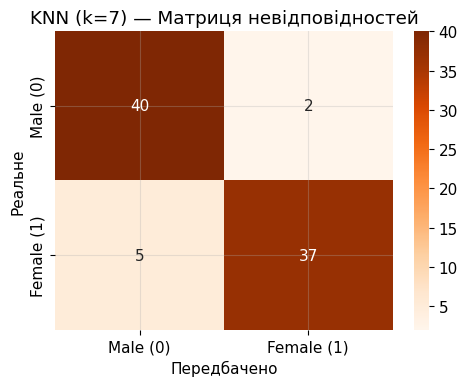

Метрики KNN:


,Accuracy,Precision,Recall,F1-score
0,0.9167,0.9487,0.881,0.9136


In [5]:
from sklearn.neighbors import KNeighborsClassifier

# Пошук найкращого k серед непарних значень
k_values = [3, 7, 11, 15, 21]
knn_results = {}
for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_sc, y_train)
    f1_k = f1_score(y_test, knn_tmp.predict(X_test_sc))
    knn_results[k] = f1_k
    print(f"k={k:>2}: F1={f1_k:.4f}")

best_k = max(knn_results, key=knn_results.get)
print(f"\nОбране k = {best_k} (найкращий F1)")

# Навчання з найкращим k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

# Confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Male (0)', 'Female (1)'],
            yticklabels=['Male (0)', 'Female (1)'], ax=ax)
ax.set_xlabel('Передбачено')
ax.set_ylabel('Реальне')
ax.set_title(f'KNN (k={best_k}) — Матриця невідповідностей')
plt.tight_layout()
plt.show()

# Метрики
metrics_knn = pd.DataFrame([{
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1-score': f1_score(y_test, y_pred_knn),
}]).round(4)
print("Метрики KNN:")
display(metrics_knn)


**Bias-Variance при різних k:**

При малому k (наприклад, k=1) модель запам'ятовує тренувальні дані — низьке зміщення, висока дисперсія (overfitting). При великому k (наприклад, k=n) модель усереднює все — високе зміщення, низька дисперсія (underfitting). Оптимальне k знаходить баланс між цими двома крайнощами.


### 2.3 Порівняння моделей: ROC, AUC та крос-валідація

- На одному графіку побудуйте ROC-криві для обох моделей. Додайте діагональ — лінію випадкового класифікатора. На легенді вкажіть значення AUC для кожної моделі.


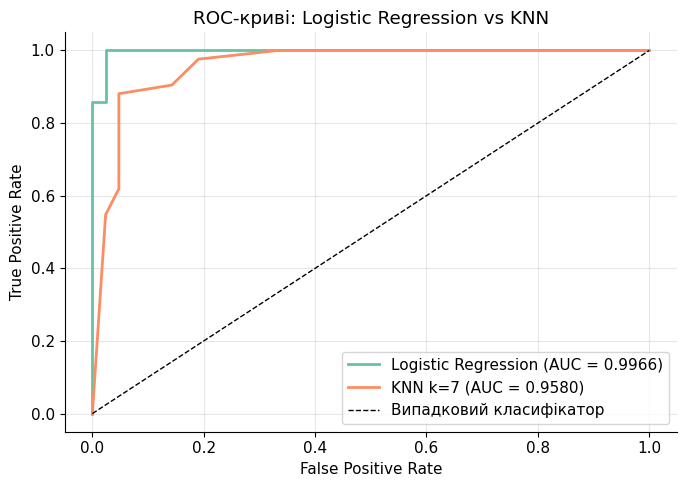

AUC Logistic Regression: 0.9966
AUC KNN (k=7):    0.9580

Краща модель: Logistic Regression


In [6]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
y_prob_knn = knn.predict_proba(X_test_sc)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_lr = auc(fpr_lr, tpr_lr)
auc_knn = auc(fpr_knn, tpr_knn)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linewidth=2)
ax.plot(fpr_knn, tpr_knn, label=f'KNN k={best_k} (AUC = {auc_knn:.4f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Випадковий класифікатор')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-криві: Logistic Regression vs KNN')
ax.legend()
plt.tight_layout()
plt.show()

print(f"AUC Logistic Regression: {auc_lr:.4f}")
print(f"AUC KNN (k={best_k}):    {auc_knn:.4f}")
print(f"\nКраща модель: {'Logistic Regression' if auc_lr >= auc_knn else f'KNN k={best_k}'}")


---

## Розділ 3. Аналіз помилок та вибір порогу

За замовчуванням класифікатори використовують поріг 0.5: якщо передбачена ймовірність позитивного класу більша за 0.5 — передбачаємо «1», інакше — «0». Але цей поріг рідко є оптимальним з точки зору бізнес-задачі.

### 3.1 Аналіз порогу та сценарій

Працюйте з кращою моделлю з Розділу 2.

**Аналіз залежності метрик від порогу.**
- Побудуйте графік, на якому показано, як змінюються **precision, recall та F1-score** залежно від порогу класифікації (від 0.0 до 1.0, наприклад, з кроком 0.05).
- Знайдіть поріг, який максимізує F1-score на тестовій вибірці. Виведіть це значення та відповідні значення precision і recall.
- У markdown-комірці поясніть: чому при збільшенні порогу precision зростає, а recall зменшується?

**Cценарій.** Ви — частина дослідницької команди, що вивчає репродуктивну поведінку пінгвінів у польових умовах. Команда планує неінвазивне спостереження за самками під час сезону розмноження. Ваша модель — інструмент попереднього скринінгу за фотографіями, який позначає особин, що, ймовірно, є самками. Дослідниця ставить вимогу: **recall для класу «Female» повинен бути не менше 0.95** — модель має знайти щонайменше 95% реальних самок у колонії, навіть якщо це означатиме, що деякі самці будуть помилково позначені (їх у будь-якому разі відсіюватимуть на наступному, ручному, етапі перевірки).

- Знайдіть **максимальний** поріг класифікації, що забезпечує цю вимогу (recall ≥ 0.95).
- Виведіть для цього порогу повний звіт: confusion matrix, accuracy, precision, recall, F1.


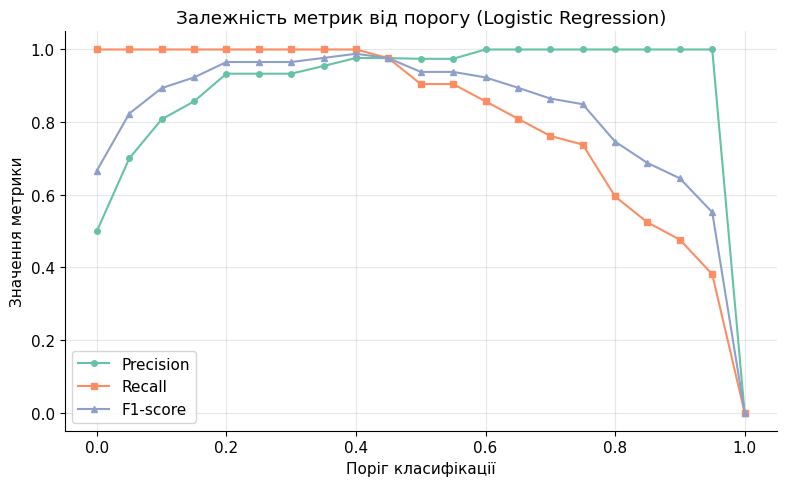

Оптимальний поріг за F1: 0.40
  Precision: 0.9767
  Recall:    1.0000
  F1-score:  0.9882

Максимальний поріг при recall >= 0.95: 0.45


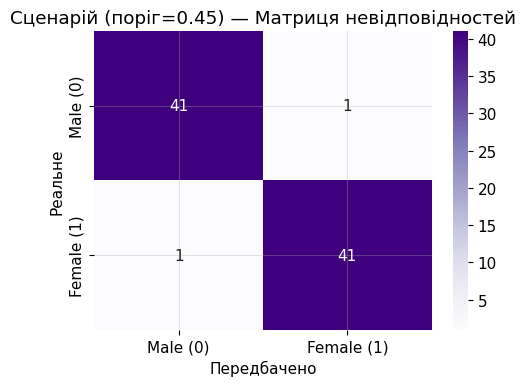

Метрики для сценарію (recall >= 0.95):


,Поріг,Accuracy,Precision,Recall,F1-score
0,0.45,0.9762,0.9762,0.9762,0.9762


In [7]:
# Використовуємо кращу модель (Logistic Regression)
best_proba = y_prob_lr  # LR має вищий AUC

thresholds = np.arange(0.0, 1.01, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (best_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

# Графік залежності метрик від порогу
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions, label='Precision', marker='o', markersize=4)
ax.plot(thresholds, recalls, label='Recall', marker='s', markersize=4)
ax.plot(thresholds, f1s, label='F1-score', marker='^', markersize=4)
ax.set_xlabel('Поріг класифікації')
ax.set_ylabel('Значення метрики')
ax.set_title('Залежність метрик від порогу (Logistic Regression)')
ax.legend()
plt.tight_layout()
plt.show()

# Оптимальний поріг за F1
best_idx = np.argmax(f1s)
best_thresh = thresholds[best_idx]
print(f"Оптимальний поріг за F1: {best_thresh:.2f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")
print(f"  F1-score:  {f1s[best_idx]:.4f}")

print()

# --- Сценарій: recall >= 0.95 ---
# Шукаємо максимальний поріг, при якому recall >= 0.95
scenario_thresh = None
for t, r in zip(thresholds[::-1], recalls[::-1]):
    if r >= 0.95:
        scenario_thresh = t
        break

print(f"Максимальний поріг при recall >= 0.95: {scenario_thresh:.2f}")

y_pred_sc = (best_proba >= scenario_thresh).astype(int)

# Confusion matrix для сценарію
cm_sc = confusion_matrix(y_test, y_pred_sc)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_sc, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Male (0)', 'Female (1)'],
            yticklabels=['Male (0)', 'Female (1)'], ax=ax)
ax.set_xlabel('Передбачено')
ax.set_ylabel('Реальне')
ax.set_title(f'Сценарій (поріг={scenario_thresh:.2f}) — Матриця невідповідностей')
plt.tight_layout()
plt.show()

metrics_sc = pd.DataFrame([{
    'Поріг': scenario_thresh,
    'Accuracy': accuracy_score(y_test, y_pred_sc),
    'Precision': precision_score(y_test, y_pred_sc),
    'Recall': recall_score(y_test, y_pred_sc),
    'F1-score': f1_score(y_test, y_pred_sc),
}]).round(4)
print("Метрики для сценарію (recall >= 0.95):")
display(metrics_sc)


**Чому при збільшенні порогу precision зростає, а recall зменшується?**

При вищому порозі модель передбачає «Female» лише для тих зразків, у яких вона дуже впевнена — серед них менше помилок, тому precision зростає. Водночас реальні «Female» з меншою ймовірністю не проходять цей жорсткіший фільтр — модель пропускає більше з них, тому recall зменшується.
